# Ethiopia Food Prices — 10 SPIKE CLASSIFICATION

Rather than forecasting the exact next-month price, this notebook asks a narrower, arguably more
actionable question: **will this market/commodity series spike next month?** (`target_next_is_spike`,
prepared in `08 FEATURE ENGINEERING`). This is a binary classification problem, and — as is typical for
spike/anomaly detection — a heavily **imbalanced** one.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib, json

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (roc_auc_score, roc_curve, precision_recall_curve, average_precision_score,
                              confusion_matrix, classification_report)

sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams['figure.dpi'] = 110
pd.set_option('display.max_columns', 30)

df = pd.read_csv('../data/eth_food_prices_features.csv', parse_dates=['date'])
print(f'{len(df):,} rows loaded')


51,071 rows loaded


## 10.1 Build the modelling table

In [2]:
NUMERIC_FEATURES = [
    'usdprice_lag1', 'usdprice_lag2', 'usdprice_lag3', 'usdprice_lag6', 'usdprice_lag12',
    'usdprice_rollmean3', 'usdprice_rollstd3', 'usdprice_rollmean6', 'usdprice_rollstd6',
    'usdprice_rollmean12', 'usdprice_rollstd12',
    'spike_rate_trailing12', 'months_since_last_spike',
    'month_sin', 'month_cos', 'years_since_start', 'price_premium_pct', 'implied_fx',
]
CATEGORICAL_FEATURES = ['admin1', 'category', 'commodity']
TARGET = 'target_next_is_spike'

model_df = df.dropna(subset=NUMERIC_FEATURES + [TARGET]).copy()
model_df[TARGET] = model_df[TARGET].astype(int)
print(f'{len(model_df):,} rows with complete features and a valid target')
print(f'Positive class (spike next month) rate: {model_df[TARGET].mean()*100:.2f}%')


20,849 rows with complete features and a valid target
Positive class (spike next month) rate: 3.18%


In [3]:
CUTOFF = pd.Timestamp('2025-07-01')
train = model_df[model_df['date'] < CUTOFF].copy()
test = model_df[model_df['date'] >= CUTOFF].copy()
print(f'Train: {len(train):,} rows, {train[TARGET].sum()} positive ({train[TARGET].mean()*100:.2f}%)')
print(f'Test : {len(test):,} rows, {test[TARGET].sum()} positive ({test[TARGET].mean()*100:.2f}%)')


Train: 16,377 rows, 513 positive (3.13%)
Test : 4,472 rows, 151 positive (3.38%)


Same chronological split as `09`, for consistency. With only ~3% of rows positive, **accuracy is a
misleading metric** here — a model that always predicts "no spike" would score ~97% accuracy while being
useless. ROC-AUC, precision/recall, and especially **PR-AUC** (precision-recall area under curve, more
informative than ROC-AUC under heavy imbalance) are used instead.


## 10.2 Logistic Regression (class-weighted, one-hot categoricals)

In [4]:
X_cols = NUMERIC_FEATURES + CATEGORICAL_FEATURES
y_train, y_test = train[TARGET], test[TARGET]

logit_pipe = Pipeline([
    ('prep', ColumnTransformer([
        ('num', StandardScaler(), NUMERIC_FEATURES),
        ('cat', OneHotEncoder(handle_unknown='ignore', min_frequency=20), CATEGORICAL_FEATURES),
    ])),
    ('model', LogisticRegression(max_iter=2000, class_weight='balanced', C=1.0)),
])
logit_pipe.fit(train[X_cols], y_train)
logit_proba = logit_pipe.predict_proba(test[X_cols])[:, 1]
print('Logistic Regression fitted.')


Logistic Regression fitted.


## 10.3 Random Forest (class-weighted, ordinal categoricals)

In [5]:
rf_pipe = Pipeline([
    ('prep', ColumnTransformer([
        ('num', 'passthrough', NUMERIC_FEATURES),
        ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), CATEGORICAL_FEATURES),
    ])),
    ('model', RandomForestClassifier(n_estimators=400, max_depth=10, min_samples_leaf=5,
                                      class_weight='balanced', random_state=42, n_jobs=-1)),
])
rf_pipe.fit(train[X_cols], y_train)
rf_proba = rf_pipe.predict_proba(test[X_cols])[:, 1]
print('Random Forest fitted.')


Random Forest fitted.


## 10.4 Histogram Gradient Boosting (native categorical support)

In [6]:
train_hgb, test_hgb = train.copy(), test.copy()
for c in CATEGORICAL_FEATURES:
    train_hgb[c] = train_hgb[c].astype('category')
    test_hgb[c] = pd.Categorical(test_hgb[c], categories=train_hgb[c].cat.categories)

# class_weight is approximated via sample_weight, since HGB classifier doesn't take class_weight directly
pos_weight = (train[TARGET] == 0).sum() / (train[TARGET] == 1).sum()
sample_weight = np.where(train[TARGET] == 1, pos_weight, 1.0)

hgb_model = HistGradientBoostingClassifier(
    max_iter=300, max_depth=6, learning_rate=0.05,
    categorical_features=CATEGORICAL_FEATURES, random_state=42,
)
hgb_model.fit(train_hgb[X_cols], y_train, sample_weight=sample_weight)
hgb_proba = hgb_model.predict_proba(test_hgb[X_cols])[:, 1]
print('Hist Gradient Boosting fitted.')


/tmp/ipykernel_250/2512193976.py:4: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  test_hgb[c] = pd.Categorical(test_hgb[c], categories=train_hgb[c].cat.categories)


Hist Gradient Boosting fitted.


## 10.5 Compare models — ROC and Precision-Recall curves

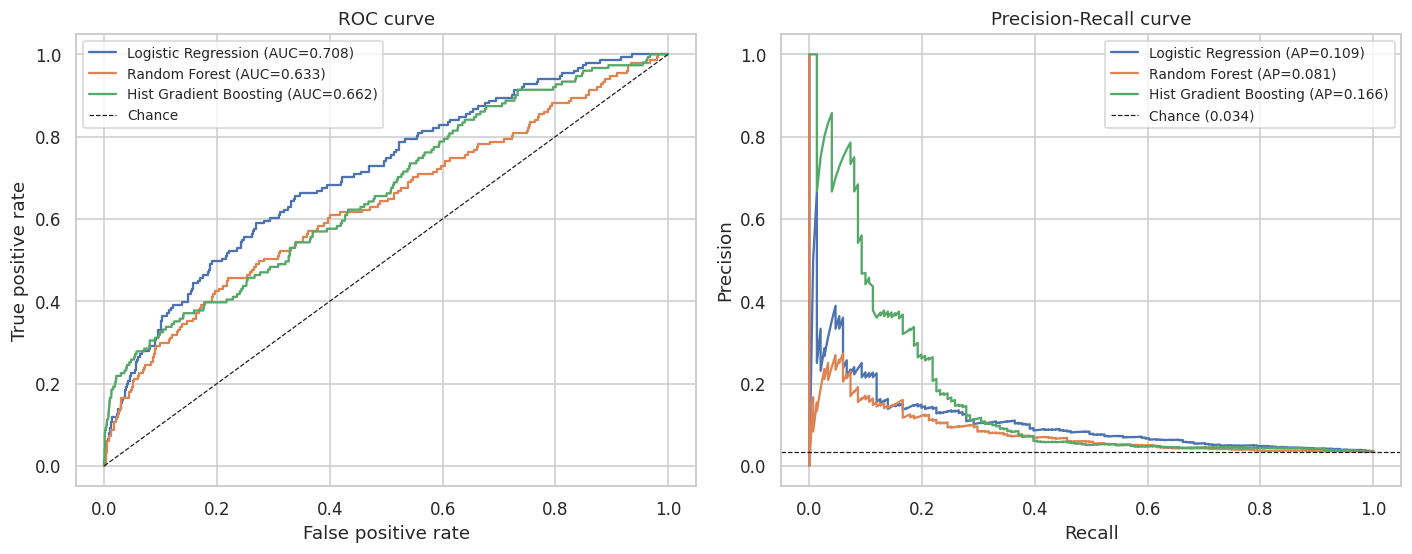

In [7]:
models_proba = {
    'Logistic Regression': logit_proba,
    'Random Forest': rf_proba,
    'Hist Gradient Boosting': hgb_proba,
}

fig, axes = plt.subplots(1, 2, figsize=(13, 5.2))
for name, proba in models_proba.items():
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    axes[0].plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})')

    prec, rec, _ = precision_recall_curve(y_test, proba)
    ap = average_precision_score(y_test, proba)
    axes[1].plot(rec, prec, label=f'{name} (AP={ap:.3f})')

axes[0].plot([0, 1], [0, 1], 'k--', linewidth=0.8, label='Chance')
axes[0].set_xlabel('False positive rate'); axes[0].set_ylabel('True positive rate')
axes[0].set_title('ROC curve'); axes[0].legend(fontsize=9)

base_rate = y_test.mean()
axes[1].axhline(base_rate, color='k', linestyle='--', linewidth=0.8, label=f'Chance ({base_rate:.3f})')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall curve'); axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()


In [8]:
summary = pd.DataFrame([
    {'Model': name, 'ROC-AUC': roc_auc_score(y_test, proba), 'PR-AUC (avg precision)': average_precision_score(y_test, proba)}
    for name, proba in models_proba.items()
]).sort_values('PR-AUC (avg precision)', ascending=False).reset_index(drop=True)
summary


,Model,ROC-AUC,PR-AUC (avg precision)
0,Hist Gradient Boosting,0.661688,0.166249
1,Logistic Regression,0.707877,0.108542
2,Random Forest,0.633322,0.081077


PR-AUC is the more trustworthy ranking metric here given the ~3% positive rate — ROC-AUC can look
deceptively good under imbalance because true negatives are so plentiful. The model with the highest PR-AUC
is the one that actually ranks true spikes above non-spikes most reliably when it matters (i.e., among the
cases flagged as high-risk).


## 10.6 Confusion matrix at a chosen decision threshold

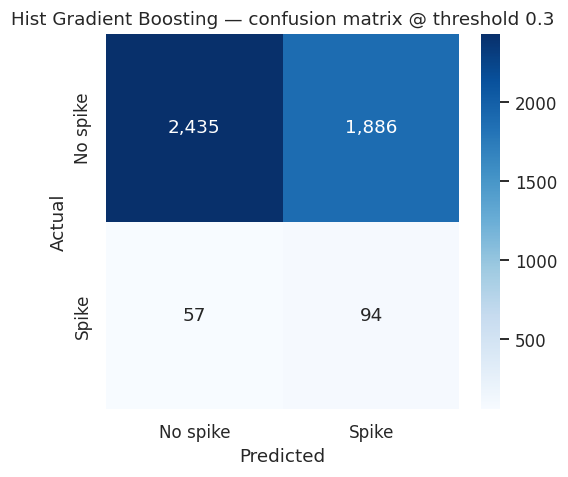

              precision    recall  f1-score   support

    No spike       0.98      0.56      0.71      4321
       Spike       0.05      0.62      0.09       151

    accuracy                           0.57      4472
   macro avg       0.51      0.59      0.40      4472
weighted avg       0.95      0.57      0.69      4472



In [9]:
best_name = summary.iloc[0]['Model']
best_proba = models_proba[best_name]

THRESHOLD = 0.3  # lower than 0.5 on purpose: missing a real spike is costlier than a false alarm here
pred_labels = (best_proba >= THRESHOLD).astype(int)

cm = confusion_matrix(y_test, pred_labels)
fig, ax = plt.subplots(figsize=(5, 4.5))
sns.heatmap(cm, annot=True, fmt=',d', cmap='Blues', ax=ax,
            xticklabels=['No spike', 'Spike'], yticklabels=['No spike', 'Spike'])
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
ax.set_title(f'{best_name} — confusion matrix @ threshold {THRESHOLD}')
plt.tight_layout()
plt.show()

print(classification_report(y_test, pred_labels, target_names=['No spike', 'Spike']))


The decision threshold is deliberately set **below 0.5**: in a food-price early-warning setting, a
missed real spike (a false negative) is more costly than an unnecessary alert (a false positive) — an
analyst reviewing a few extra flagged markets is a much smaller cost than missing an actual price shock.
This is a threshold choice, not a modelling one, and can be tuned further using the PR curve above once the
actual cost trade-off for a specific use case is known.


## 10.7 Where does the model find risk? — region and commodity

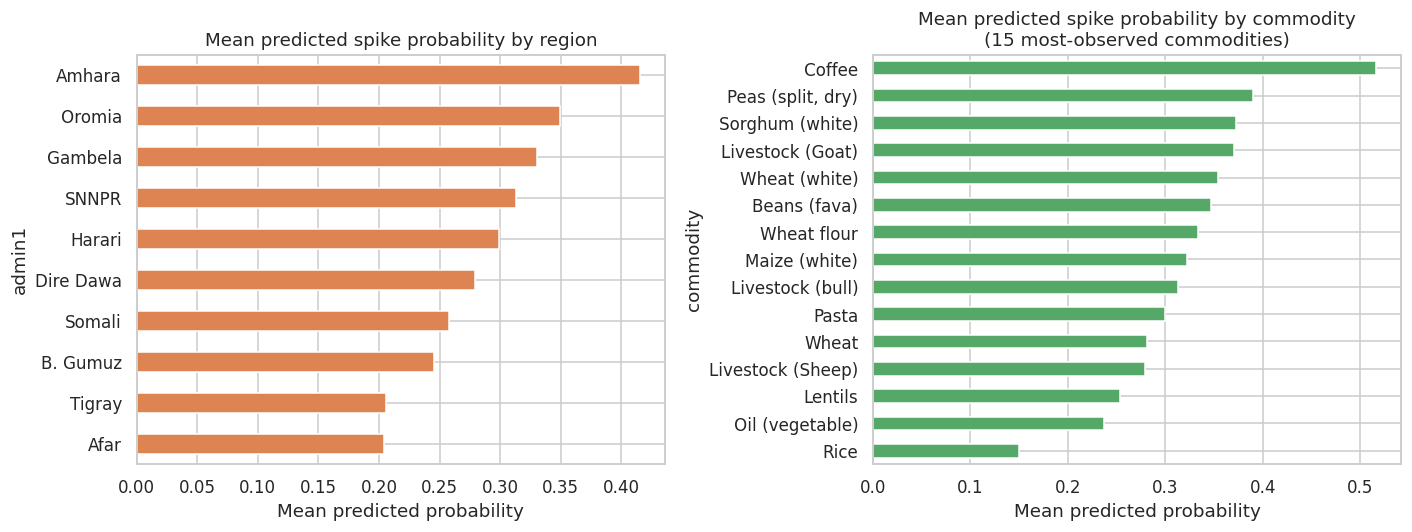

In [10]:
test_eval = test.copy()
test_eval['proba'] = best_proba

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

region_risk = test_eval.groupby('admin1', observed=True)['proba'].mean().sort_values()
region_risk.plot(kind='barh', ax=axes[0], color='#DD8452')
axes[0].set_title('Mean predicted spike probability by region')
axes[0].set_xlabel('Mean predicted probability')

top_commodities = test_eval['commodity'].value_counts().head(15).index
comm_risk = test_eval[test_eval['commodity'].isin(top_commodities)].groupby('commodity', observed=True)['proba'].mean().sort_values()
comm_risk.plot(kind='barh', ax=axes[1], color='#55A868')
axes[1].set_title('Mean predicted spike probability by commodity\n(15 most-observed commodities)')
axes[1].set_xlabel('Mean predicted probability')

plt.tight_layout()
plt.show()


Compare this to the *actual* regional/commodity spike-rate rankings from `04 SPIKE ANALYSIS` (§4.5–4.6) — a well-calibrated model's predicted-risk ranking should broadly line up with where spikes actually concentrated historically, which is a useful sanity check independent of the formal AUC/PR metrics above.

## 10.8 Save models and predictions

In [11]:
joblib.dump(logit_pipe, '../models/10_logistic_regression.joblib')
joblib.dump(rf_pipe, '../models/10_random_forest_classifier.joblib')
joblib.dump(hgb_model, '../models/10_hist_gb_classifier.joblib')

with open('../models/10_feature_config.json', 'w') as f:
    json.dump({'numeric_features': NUMERIC_FEATURES, 'categorical_features': CATEGORICAL_FEATURES,
               'target': TARGET, 'cutoff_date': str(CUTOFF.date()), 'decision_threshold': THRESHOLD}, f, indent=2)

predictions_out = test[['date', 'admin1', 'market', 'commodity', 'commodity_unit', TARGET]].copy()
predictions_out['proba_logistic'] = logit_proba
predictions_out['proba_random_forest'] = rf_proba
predictions_out['proba_hist_gb'] = hgb_proba
predictions_out.to_csv('../data/10_classification_test_predictions.csv', index=False)

summary.to_csv('../data/10_classification_model_scores.csv', index=False)
print('Saved 3 classifiers, feature config, test predictions, and score table.')


Saved 3 classifiers, feature config, test predictions, and score table.


---
## Summary

- Framed next-month spike risk as **binary classification** on the same feature matrix and chronological
  split as `09`, with the ~3% positive rate handled via class weighting and PR-AUC as the primary ranking
  metric (ROC-AUC alone would overstate performance under this imbalance).
- Compared Logistic Regression, Random Forest, and Histogram Gradient Boosting via ROC and Precision-Recall
  curves — see the scored table above for the winner.
- Used a **below-0.5 decision threshold**, reflecting that a missed real spike is costlier than a false
  alarm in an early-warning use case — a business decision, tunable independently of the model itself.
- Predicted spike-risk broadly tracks the actual historical spike-rate patterns found in `04 SPIKE
  ANALYSIS`, a useful independent sanity check.
- Saved all three classifiers, feature configuration, and test-set predictions for `11 MODEL COMPARISON`,
  `12 EXPLAINABILITY`, and `13 FINAL MODELS`.
